# Function 5 — 4D Chemical Process Yield

**Objective:** maximise yield
**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI), ξ = 0.01 — tight exploitation
**Y transform:** `log(Y + offset)`, offset = 4.789

---

Four process inputs in [0, 1], returning a yield. One query per week, five
rounds completed.

**This is the best result in the project: 1089 → 2757, a 153% improvement.**

The problem description says the surface is unimodal with a single dominant
peak, which shaped every decision below — moderate exploration early, then
tight exploitation once the peak region was located.

With four inputs the surface cannot be drawn directly, so the visualisation
shows all C(4,2) = 6 pairwise slices, fixing the other two axes at the next
sample's values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_5.csv` rather than pasted inline.

In the original script `X` had grown to 26 rows while `Y_raw` had 25 values — a
pending round-6 query, `[0.37931, 1.0, 1.0, 1.0]`, had been added before its
result came back. `model.fit(X, Y)` raises a shape-mismatch error in that
state.

Keeping observations in one file with a `week` column makes that impossible: a
row without a result does not exist yet.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_5.csv", float_precision="round_trip")

X     = df[["x1", "x2", "x3", "x4"]].values   # process inputs
Y_raw = df["y"].values                        # yield
week  = df["week"].values                     # 0 = supplied, 1-5 = ours

print("Data shapes:")
print(f"  X     : {X.shape}")
print(f"  Y_raw : {Y_raw.shape}")
print(f"\nY_raw range : [{Y_raw.min():.4f},  {Y_raw.max():.4f}]")
print(f"Rounds present: {sorted(set(week))}")

df.tail(6)

Data shapes:
  X     : (25, 4)
  Y_raw : (25,)

Y_raw range : [-3.7894,  2757.0233]
Rounds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,week,x1,x2,x3,x4,y
19,0,0.126885,0.153430,0.770162,0.190518,9.972332
20,1,0.222709,0.846708,0.876134,0.878108,1072.192230
21,2,0.126750,0.154500,0.795000,0.201055,-3.789395
22,3,0.238677,0.844253,0.912281,0.882506,1269.423110
23,4,0.261006,0.840818,0.962835,0.888654,1620.024231
24,5,0.315789,0.894737,0.947368,1.000000,2757.023279


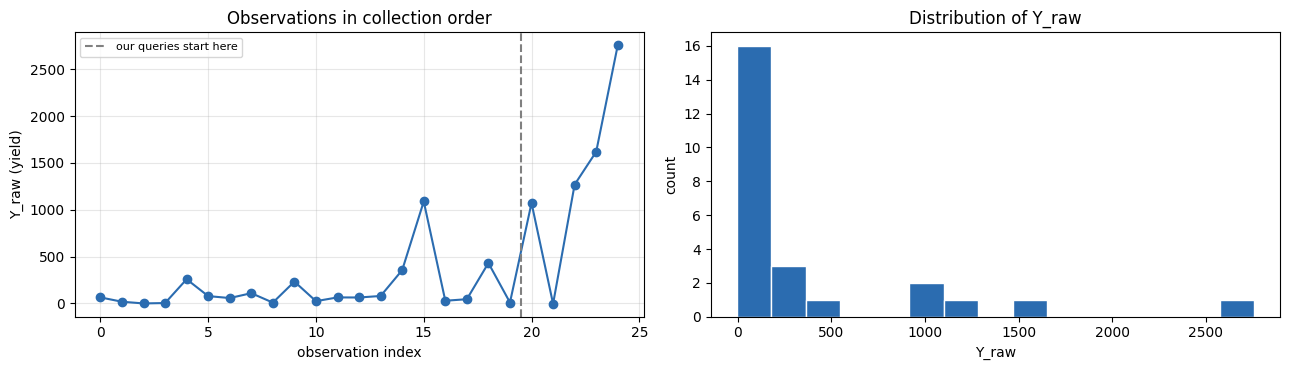

In [3]:
# Left  : yields in collection order - note the climb at the right-hand end
# Right : how the yields are distributed
#
# The rise across the last three points is the whole story of this function.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y_raw, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y_raw (yield)")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y_raw, bins=15, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y_raw")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y_raw")

plt.tight_layout()
plt.show()

## 2. Y transform — log(Y + offset)

`Y_raw` spans −3.79 to 2757, a range of roughly 700,000×. Most observations sit
below 500 while a handful reach the thousands. Left untransformed, the GP
cannot fit both ends with one length-scale.

A log compresses this, but a log is undefined for negative numbers, so
everything is shifted above zero first:

`offset = |min(Y_raw)| + 1 = 4.789`

Shifting does not change the ordering, so the best raw point remains the best
point on the transformed scale.

| Raw | Transformed | |
|---|---|---|
| −3.79 | 0.00 | the anomalous reading |
| 0.11 | 1.59 | |
| 64.44 | 4.24 | |
| 1269.42 | 7.15 | round 3 |
| 2757.02 | 7.92 | round 5, current best |

### A data quality problem

**That offset exists because of a single value, and the value is doubtful.**

The round 2 result is recorded as `−3.78939474`. It is the only negative
observation this function ever produced, and it is identical to eight decimal
places to the result recorded for **Function 4, round 1**.

Two different functions returning the exact same unusual number is far more
consistent with a copy-paste error in the submission log than with a real
measurement.

It is kept here as recorded, because silently deleting inconvenient data is
worse than documenting it. But if it is an error, the offset can be dropped
entirely and a plain `log(Y)` used instead — which would simplify the model
and remove an artificial floor from the transformed scale.

In [4]:
# -----------------------------------------------------------------
#  Y TRANSFORM  —  log(Y_raw + offset)
# -----------------------------------------------------------------
offset = abs(Y_raw.min()) + 1.0        # = 4.789, set by the one negative value
Y      = np.log(Y_raw + offset)

print(f"Offset applied      : {offset:.4f}")
print(f"Y_raw range         : [{Y_raw.min():.4f},  {Y_raw.max():.4f}]")
print(f"Y_transformed range : [{Y.min():.4f},  {Y.max():.4f}]")

# The suspicious value, and its twin in Function 4
print("\nThe one negative observation:")
odd = np.argmin(Y_raw)
print(f"  round {week[odd]}: {Y_raw[odd]:.8f}")
print("  Function 4 round 1 recorded: -3.78939474  <- identical")

Offset applied      : 4.7894
Y_raw range         : [-3.7894,  2757.0233]
Y_transformed range : [0.0000,  7.9236]

The one negative observation:
  round 2: -3.78939474
  Function 4 round 1 recorded: -3.78939474  <- identical


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | Unimodal surfaces are globally smooth with one dominant peak, so a single shared length-scale is appropriate. ARD would add complexity without benefit here. |
| `length_scale` | 0.3, bounds **(0.05, 2.0)** | The lower bound was raised from 0.01 — see the changelog below. |
| `WhiteKernel` | **0.05**, bounds (1e-5, 10.0) | Lower than Function 4's 1.0, because chemical yield measurements are relatively consistent. |

### What changed after round 5, and why

Once round 5 returned 2757 — a clear new best in an already-identified region —
the configuration was tightened deliberately:

| Setting | Before | After | Reason |
|---|---|---|---|
| ξ | 0.05 | **0.01** | A clear peak exists; exploit it rather than confirming empty regions. |
| Grid | 20⁴ | **30⁴** | Finer resolution near the peak, 810,000 candidates. |
| `length_scale` lower bound | 0.01 | **0.05** | Prevents the GP overfitting to the tight cluster of new high-yield points. |
| `WhiteKernel` initial | 0.1 | **0.05** | The recent observations are clean; allow tighter interpolation. |

This is the one function where the settings were revised in response to
results rather than set once at the start — and it is also the one that
performed best.

In [5]:
# -----------------------------------------------------------------
#  KERNEL
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # overall signal amplitude
    )
    * Matern(
        nu=2.5,                                 # smooth, single dominant peak
        length_scale=0.3,
        length_scale_bounds=(0.05, 2.0),        # floor raised from 0.01
    )
    + WhiteKernel(
        noise_level=0.05,                       # was 0.1 - cleaner data now
        noise_level_bounds=(1e-5, 10.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
# -----------------------------------------------------------------
xi = 0.01      # tight exploitation - the peak region is clear

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y)

print(f"Optimised kernel:\n  {model.kernel_}")

fitted_ls    = model.kernel_.k1.k2.length_scale
fitted_noise = model.kernel_.k2.noise_level
print(f"\n  fitted length_scale : {fitted_ls:.4g}   (started at 0.3)")
print(f"  fitted noise_level  : {fitted_noise:.4g}   (started at 0.05)")

Optimised kernel:
  0.965**2 * Matern(length_scale=0.541, nu=2.5) + WhiteKernel(noise_level=0.157)

  fitted length_scale : 0.5413   (started at 0.3)
  fitted noise_level  : 0.1566   (started at 0.05)


## 4. Does the model actually work?

Leave-one-out cross-validation: hide one observation, refit on the rest,
predict the hidden point, repeat for all 25.

Two measures are reported.

**RMSE** is the average size of the prediction error, in the units of this
function's target. It is an absolute measure — it says how wrong the model is,
not merely how it compares with an alternative — which makes it the more
interpretable of the two and the better choice when comparing different kinds
of model.

**R²** expresses the same error as a proportion of the variance: 1.0 is
perfect, 0.0 is no better than always predicting the average, and below 0.0 is
worse than that. It is unitless, so it travels between functions on different
scales, but a high value alone does not make a model appropriate.

Both are shown, along with the RMSE of simply predicting the mean, which is the
benchmark any useful model has to beat.

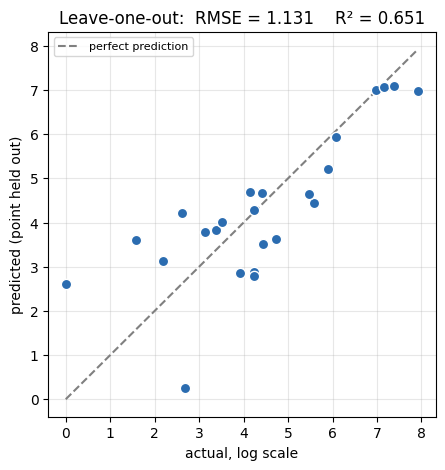

RMSE                       : 1.131
RMSE if predicting the mean: 1.915
Ratio                      : 0.591   (below 1 beats guessing)
R²                         : 0.651

The model predicts held-out points reasonably well, so its
suggestions are worth acting on.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.05, 2.0))
         + WhiteKernel(0.05, (1e-5, 10.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y - Y.mean()) ** 2).sum()

# RMSE: the average size of the prediction error, in the units of the
# target. Unlike R2 it is an absolute measure, so it says how wrong the
# model is rather than only how it compares with guessing.
rmse = np.sqrt((residuals ** 2).mean())

# RMSE we would get by always predicting the mean - the benchmark any
# useful model has to beat.
baseline = np.sqrt(((Y - Y.mean()) ** 2).mean())
ratio    = rmse / baseline

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y, predicted, s=55, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y.min(), predicted.min()), max(Y.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual, log scale")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out:  RMSE = {rmse:.4g}    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"RMSE                       : {rmse:.4g}")
print(f"RMSE if predicting the mean: {baseline:.4g}")
print(f"Ratio                      : {ratio:.3f}   (below 1 beats guessing)")
print(f"R²                         : {r2:.3f}")
if r2 >= 0.6:
    print("\nThe model predicts held-out points reasonably well, so its")
    print("suggestions are worth acting on.")
elif r2 >= 0.3:
    print("\nModerate. The model has learned real structure but is not precise.")
else:
    print("\nWeak. Treat the model's suggestions with caution.")

## 5. Prediction grid and Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z)

**ξ = 0.01** — the most exploitative setting used anywhere in this project, and
the opposite of Function 4's ξ = 0.10.

The justification is the problem description: a unimodal surface with a single
peak. Once that peak region is found there is nothing to be gained by
confirming that distant corners are empty, and with one query per week a round
spent confirming emptiness is a round not spent climbing.

The grid is 30⁴ = 810,000 candidate points, raised from 20⁴ to give finer
resolution near the peak.

In [7]:
# -----------------------------------------------------------------
#  4D PREDICTION GRID  (30^4 = 810,000 candidates)
# -----------------------------------------------------------------
n_grid = 30
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(x_vals, x_vals, x_vals, x_vals, indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

print(f"Grid size : {len(X_grid):,} points")

post_mean, post_std = model.predict(X_grid, return_std=True)


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT  (on the transformed scale)
# -----------------------------------------------------------------
Y_best = Y.max()


def expected_improvement(mu, sigma, y_best, xi=0.01):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. Set it to 0.0
    # and zero the resulting EI: a point with no uncertainty offers no
    # possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx     = np.argmax(ei_values)
x_next       = X_grid[best_idx]
best_raw_idx = np.argmax(Y_raw)

print(f"\nCurrent best Y_raw    : {Y_raw[best_raw_idx]:.4f}")
print(f"  (log scale)         : {Y[best_raw_idx]:.4f}")
print(f"  at X                : {X[best_raw_idx]}")
print(f"  found in round      : {week[best_raw_idx]}")
print(f"\nNext point to sample  : {np.round(x_next, 6).tolist()}")
print(f"Max EI value          : {ei_values[best_idx]:.6f}")

# How far is the suggestion from the current best?
print(f"\nDistance from current best: "
      f"{np.linalg.norm(x_next - X[best_raw_idx]):.4f}")
on_bound = int(np.sum((x_next <= 1e-6) | (x_next >= 0.999)))
print(f"Coordinates on the boundary: {on_bound} of 4")

Grid size : 810,000 points



Current best Y_raw    : 2757.0233
  (log scale)         : 7.9236
  at X                : [0.315789 0.894737 0.947368 1.      ]
  found in round      : 5

Next point to sample  : [0.37931, 1.0, 1.0, 1.0]
Max EI value          : 0.227126

Distance from current best: 0.1337
Coordinates on the boundary: 3 of 4


## 6. Visualisation

Eighteen panels: six pairwise slices across three rows (GP mean, uncertainty,
EI). In each panel the other two inputs are held at the next sample's values,
shown in the panel title.

What to look for here is the tight cluster of white dots near the cyan diamond
— that is the ridge the search climbed over rounds 3, 4 and 5.

A caveat on reading these: the white dots are **all** observations projected
onto the plane, including ones whose fixed coordinates are far from the slice.
A point can look adjacent to the star while being distant in the other two
dimensions.

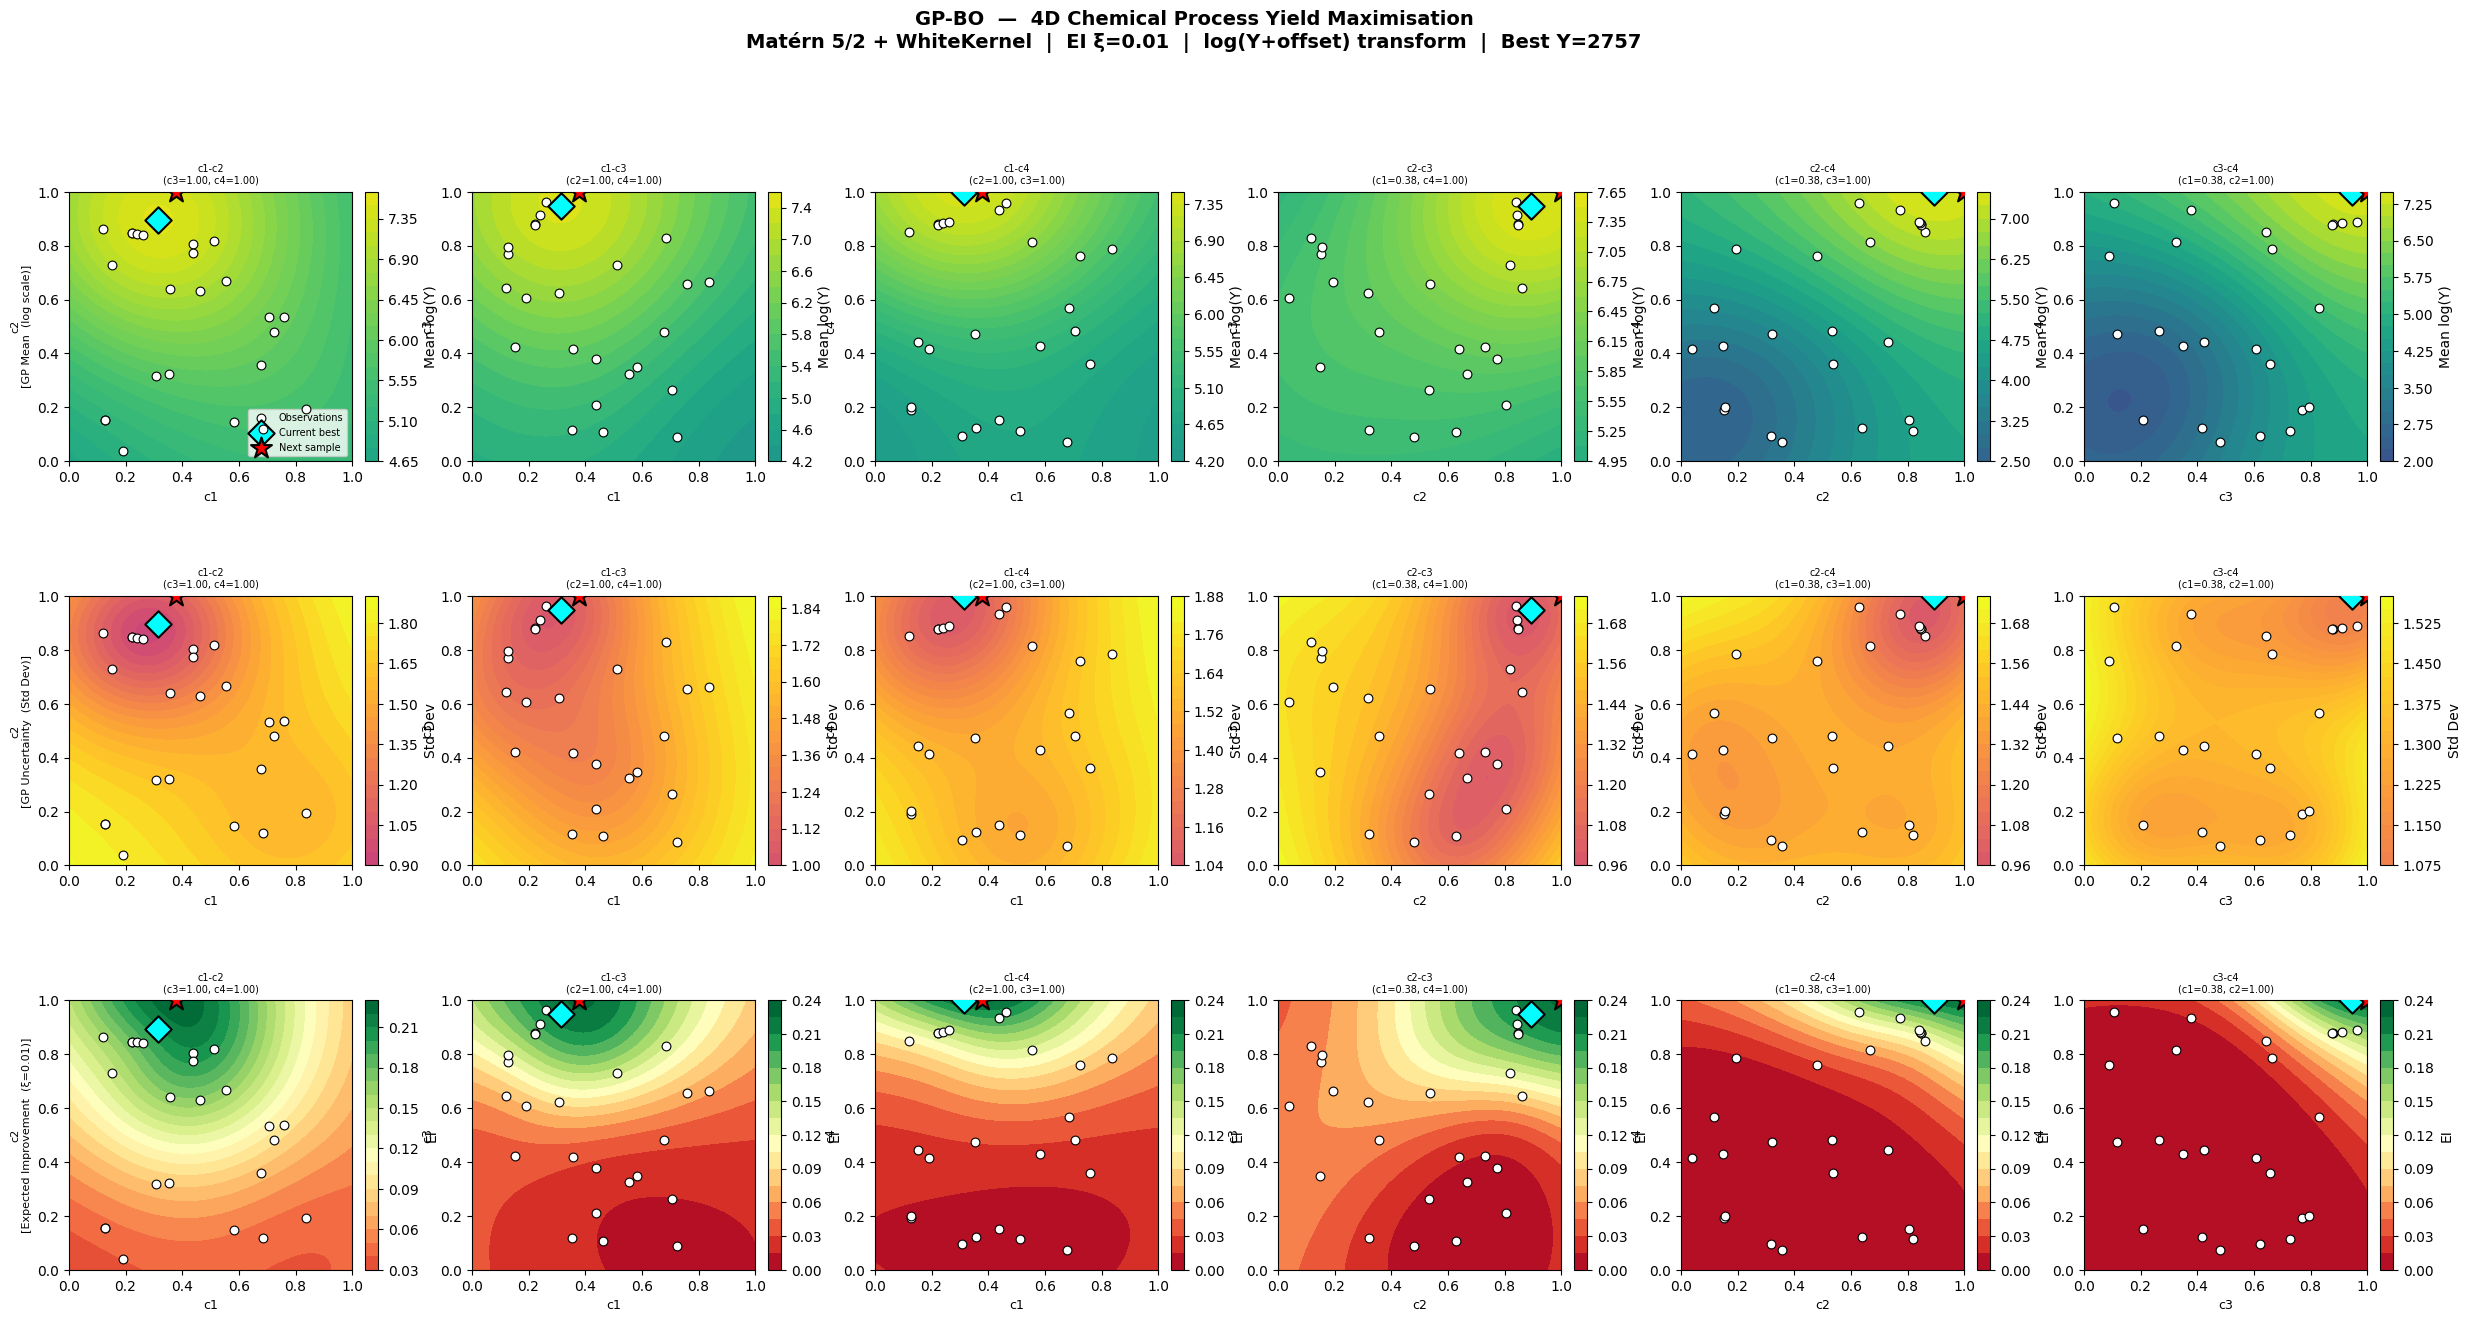

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION — C(4,2) = 6 pairwise slices, 3 rows
# -----------------------------------------------------------------
n_slice    = 80
s_vals     = np.linspace(0, 1, n_slice)
S1, S2     = np.meshgrid(s_vals, s_vals)
axis_names = ["c1", "c2", "c3", "c4"]
PAIRS      = list(combinations(range(4), 2))

ROW_LABELS = [
    "GP Mean  (log scale)",
    "GP Uncertainty  (Std Dev)",
    f"Expected Improvement  (\u03be={xi})",
]

fig = plt.figure(figsize=(30, 14))
fig.suptitle(
    "GP-BO  —  4D Chemical Process Yield Maximisation\n"
    f"Mat\u00e9rn 5/2 + WhiteKernel  |  EI \u03be={xi}  |  log(Y+offset) transform  "
    f"|  Best Y={Y_raw[best_raw_idx]:.0f}",
    fontsize=14, fontweight="bold", y=1.01,
)
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.50, wspace=0.30)

for row in range(3):
    for col, (ax_a, ax_b) in enumerate(PAIRS):

        ax = fig.add_subplot(gs[row, col])

        fixed_axes = [i for i in range(4) if i not in (ax_a, ax_b)]
        title_fix  = ", ".join(
            f"{axis_names[i]}={x_next[i]:.2f}" for i in fixed_axes
        )

        grid          = np.tile(x_next, (n_slice ** 2, 1))
        grid[:, ax_a] = S1.ravel()
        grid[:, ax_b] = S2.ravel()

        mu_sl, std_sl = model.predict(grid, return_std=True)
        ei_sl = expected_improvement(mu_sl, std_sl, Y_best, xi)

        if row == 0:
            Z, cmap    = mu_sl.reshape(n_slice, n_slice), "viridis"
            vmin, vmax = Y.min(), Y.max()
            cb_label   = "Mean log(Y)"
        elif row == 1:
            Z, cmap    = std_sl.reshape(n_slice, n_slice), "plasma"
            vmin, vmax = 0, std_sl.max()
            cb_label   = "Std Dev"
        else:
            Z, cmap    = ei_sl.reshape(n_slice, n_slice), "RdYlGn"
            vmin, vmax = 0, max(ei_sl.max(), 1e-9)
            cb_label   = "EI"

        cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap, vmin=vmin, vmax=vmax)

        ax.scatter(X[:, ax_a], X[:, ax_b], c="white", s=40,
                   edgecolors="black", linewidths=0.8, zorder=10,
                   label="Observations")
        ax.scatter(X[best_raw_idx, ax_a], X[best_raw_idx, ax_b],
                   c="cyan", s=180, marker="D", edgecolors="black",
                   linewidths=1.5, zorder=11, label="Current best")
        ax.scatter(x_next[ax_a], x_next[ax_b], c="red", s=250,
                   marker="*", edgecolors="black", linewidths=1.5,
                   zorder=12, label="Next sample")

        ax.set_xlabel(axis_names[ax_a], fontsize=9)
        ax.set_title(f"{axis_names[ax_a]}-{axis_names[ax_b]}\n({title_fix})",
                     fontsize=7)

        if col == 0:
            ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]", fontsize=8)
        else:
            ax.set_ylabel(axis_names[ax_b], fontsize=9)

        plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc="lower right")

plt.show()

## 7. Round-by-round review

**The best result in the project: 1088.86 → 2757.02, a 153% improvement**, with
gains in rounds 3, 4 and 5.

| Round | Query | Y_raw | Best after | Improved |
|---|---|---|---|---|
| 1 | [0.223, 0.847, 0.876, 0.878] | 1072.19 | 1088.86 | no |
| 2 | [0.127, 0.155, 0.795, 0.201] | −3.79 | 1088.86 | no |
| 3 | [0.239, 0.844, 0.912, 0.883] | 1269.42 | 1269.42 | **yes** |
| 4 | [0.261, 0.841, 0.963, 0.889] | 1620.02 | 1620.02 | **yes** |
| 5 | [0.316, 0.895, 0.947, 1.000] | 2757.02 | 2757.02 | **yes** |

**Why this one worked.** Rounds 1, 3, 4 and 5 all sit in a single tight region
around [0.22–0.32, 0.84–0.90, 0.88–0.96, 0.88–1.00], and each step moved a
short distance from the last. That is what a successful climb looks like: not a
search of the whole space, but a sequence of small moves up a ridge.

Compare this with Function 4, where four of five queries were scattered across
the boundary. Same dimensionality, same kernel family, same acquisition
function — the difference is that Function 5's ξ kept the search local while
Function 4's sent it to the corners.

The unimodality described in the problem statement turned out to be real, and
trusting it was the right call.

**Round 2 is the exception**, sampling a distant region and returning the
anomalous −3.79. That value is itself suspect (section 2), so the single
non-improving interior round may not be a real result at all.

**Two things to be careful about:**

1. **The fourth input reached exactly 1.0 in round 5.** The optimum may sit on
   the boundary of the allowed range, where no interior search can improve on
   it. If so, the true best is at the edge and the remaining gain is in the
   other three coordinates.

2. **This trajectory was cut short, not completed.** The gains were
   *accelerating* — +180, +351, +1137 across rounds 3, 4 and 5. A search still
   climbing that steeply when submissions ended has not converged, and the
   final number understates what the method would have reached.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    prev_best = Y_raw[week < r].max()
    rows.append({
        "round":      r,
        "submitted":  "[" + ", ".join(f"{v:.3f}" for v in X[i]) + "]",
        "Y_raw":      round(float(Y_raw[i]), 2),
        "best after": round(float(Y_raw[week <= r].max()), 2),
        "gain":       round(float(Y_raw[week <= r].max() - prev_best), 2),
        "improved":   "yes" if Y_raw[i] > prev_best else "no",
    })

pd.DataFrame(rows)

,round,submitted,Y_raw,best after,gain,improved
0,1,"[0.223, 0.847, 0.876, 0.878]",1072.19,1088.86,0.00,no
1,2,"[0.127, 0.154, 0.795, 0.201]",-3.79,1088.86,0.00,no
2,3,"[0.239, 0.844, 0.912, 0.883]",1269.42,1269.42,180.56,yes
3,4,"[0.261, 0.841, 0.963, 0.889]",1620.02,1620.02,350.60,yes
4,5,"[0.316, 0.895, 0.947, 1.000]",2757.02,2757.02,1137.00,yes


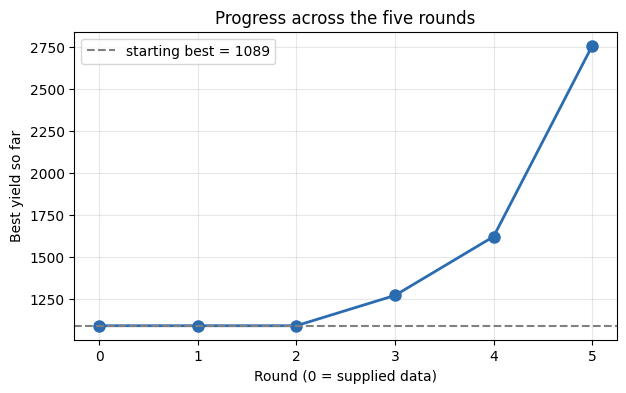

Gain per round: +0 +0 +181 +351 +1137


In [10]:
# Best yield so far, after each round.
#
# The rising steepness across rounds 3 to 5 is the point: the gains were
# accelerating when submissions stopped, so this search was truncated
# rather than converged.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y_raw[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.0f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best yield so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

gains = np.diff(best_so_far)
print("Gain per round:", " ".join(f"{g:+.0f}" for g in gains))

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
start_best = Y_raw[week == 0].max()

print("=" * 65)
print("Summary — Chemical Process Yield 4D")
print("=" * 65)
print(f"  Total observations        : {len(X)}")
print(f"  Best Y_raw so far         : {Y_raw[best_raw_idx]:.4f}")
print(f"  at X                      : {X[best_raw_idx]}")
print(f"  Found in round            : {week[best_raw_idx]}")
print(f"  Starting best             : {start_best:.4f}")
print(f"  Improvement               : {(Y_raw.max() - start_best) / start_best * 100:+.1f}%")
print(f"  Y transform               : log(Y_raw + {offset:.4f})")
print(f"  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel")
print(f"  Fitted length_scale       : {fitted_ls:.4g}")
print(f"  Fitted noise_level        : {fitted_noise:.4g}")
print(f"  Model quality (R2)        : {r2:.3f}")
print(f"  EI xi parameter           : {xi}  (tight exploitation)")
print(f"  Grid resolution           : {n_grid}^4 = {n_grid**4:,} points")
print(f"  Next point to sample      : {np.round(x_next, 6).tolist()}")
print(f"  Max EI value              : {ei_values[best_idx]:.6f}")
print("=" * 65)

Summary — Chemical Process Yield 4D
  Total observations        : 25
  Best Y_raw so far         : 2757.0233
  at X                      : [0.315789 0.894737 0.947368 1.      ]
  Found in round            : 5
  Starting best             : 1088.8596
  Improvement               : +153.2%
  Y transform               : log(Y_raw + 4.7894)
  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel
  Fitted length_scale       : 0.5413
  Fitted noise_level        : 0.1566
  Model quality (R2)        : 0.651
  EI xi parameter           : 0.01  (tight exploitation)
  Grid resolution           : 30^4 = 810,000 points
  Next point to sample      : [0.37931, 1.0, 1.0, 1.0]
  Max EI value              : 0.227126


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, and `DATASHEET.md` for known gaps
and biases in the data — including the suspect round 2 value discussed above.